In [ ]:
# ======================================================================
# Célula 1: Setup inicial - GPU, versões e instalação de bibliotecas
# ======================================================================

import sys, subprocess, textwrap

def pip_install(pkg):
    print(f"\n>>> Instalando {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Verifica GPU
import tensorflow as tf
print("Versão do TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs disponíveis:", gpus)

if not gpus:
    print("\n⚠️ Nenhuma GPU detectada. No Colab, ative: Runtime > Change runtime type > GPU.")

# Instalar bibliotecas adicionais
try:
    import xgboost
    print("XGBoost já instalado:", xgboost.__version__)
except ImportError:
    pip_install("xgboost")

try:
    import imblearn
    print("imblearn já instalado:", imblearn.__version__)
except ImportError:
    pip_install("imblearn")

try:
    from scikeras.wrappers import KerasClassifier
    print("SciKeras já instalado.")
except Exception:
    pip_install("scikeras")

print("\n✅ Setup inicial concluído.")


Versão do TensorFlow: 2.19.0
GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
XGBoost já instalado: 3.1.2
imblearn já instalado: 0.14.0

>>> Instalando scikeras ...

✅ Setup inicial concluído.


In [ ]:
# ======================================================================
# Célula 2: Imports e configuração global
# ======================================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score, make_scorer, accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from scikeras.wrappers import KerasClassifier

# Configurações gerais
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Scorer principal: F1 da classe positiva (risco_credito = 1)
f1_pos_scorer = make_scorer(f1_score, pos_label=1)

print("✅ Imports concluídos e seeds configurados.")


✅ Imports concluídos e seeds configurados.


In [ ]:
# ======================================================================
# Célula 3: Leitura da base e estatística descritiva
# ======================================================================

CSV_PATH = "/content/sample_data/transformed_dataset_oficial.csv"  # ajuste se necessário

print(f"Lendo base a partir de: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)

print("\n✅ Base carregada com sucesso!")
print(f"Formato da base: {df.shape[0]} linhas x {df.shape[1]} colunas\n")

print("📌 Primeiras linhas:")
display(df.head())

print("\n📌 Informações gerais (dtypes, missing, etc.):")
display(df.info())

print("\n📌 Verificando missing values por coluna:")
display(df.isna().sum())

# Target
TARGET_COL = "risco_credito"
assert TARGET_COL in df.columns, f"Coluna alvo '{TARGET_COL}' não encontrada!"

print("\n📌 Distribuição da variável alvo (contagem):")
display(df[TARGET_COL].value_counts())

print("\n📌 Distribuição da variável alvo (proporção):")
display(df[TARGET_COL].value_counts(normalize=True))

# Estatística descritiva dos atributos numéricos
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

print("\n📌 Estatística descritiva das variáveis numéricas (exceto alvo):")
display(df[numeric_cols].describe().T)

print("\n✅ Estatística descritiva inicial concluída.")


Lendo base a partir de: /content/sample_data/transformed_dataset_oficial.csv

✅ Base carregada com sucesso!
Formato da base: 1000 linhas x 53 colunas

📌 Primeiras linhas:


,duracao_meses,valor_emprestimo,taxa_prestacao_renda,tempo_residencia_atual,idade,num_emprestimos_atuais,num_dependentes,possui_telefone,trabalhador_estrangeiro,risco_credito,...,emprego_gestor_ou_autonomo,emprego_oficial_qualificado,emprego_desempregado_nao_residente,emprego_nao_qualificado_residente,garante,co_solicitante,proposito_carro,proposito_bens_domesticos,proposito_educacao_grupo,proposito_outros_grupo
0,6,1169,4,4,67,2,1,1,1,0,...,False,True,False,False,False,True,False,True,False,False
1,48,5951,2,2,22,1,1,0,1,1,...,False,True,False,False,False,True,False,True,False,False
2,12,2096,2,3,49,1,2,0,1,0,...,False,False,False,True,False,True,False,False,True,False
3,42,7882,2,4,45,1,2,0,1,0,...,False,True,False,False,True,True,False,True,False,False
4,24,4870,3,4,53,2,2,0,1,1,...,False,True,False,False,False,True,True,False,False,False



📌 Informações gerais (dtypes, missing, etc.):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 53 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   duracao_meses                                  1000 non-null   int64
 1   valor_emprestimo                               1000 non-null   int64
 2   taxa_prestacao_renda                           1000 non-null   int64
 3   tempo_residencia_atual                         1000 non-null   int64
 4   idade                                          1000 non-null   int64
 5   num_emprestimos_atuais                         1000 non-null   int64
 6   num_dependentes                                1000 non-null   int64
 7   possui_telefone                                1000 non-null   int64
 8   trabalhador_estrangeiro                        1000 non-null   int64
 9   risco_credito               

None


📌 Verificando missing values por coluna:


...


📌 Distribuição da variável alvo (proporção):


,proportion
risco_credito,
0,0.7
1,0.3



📌 Estatística descritiva das variáveis numéricas (exceto alvo):


,count,mean,std,min,25%,50%,75%,max
duracao_meses,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
valor_emprestimo,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
taxa_prestacao_renda,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
tempo_residencia_atual,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
idade,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
num_emprestimos_atuais,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
num_dependentes,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0
possui_telefone,1000.0,0.404,0.490943,0.0,0.0,0.0,1.00,1.0
trabalhador_estrangeiro,1000.0,0.963,0.188856,0.0,1.0,1.0,1.00,1.0



✅ Estatística descritiva inicial concluída.


In [ ]:
# ======================================================================
# Célula 4: Split treino/teste e análise do desbalanceamento
# ======================================================================

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

print(f"Dimensão de X: {X.shape}, Dimensão de y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\n📌 Distribuição da classe no conjunto de TREINO:")
display(y_train.value_counts())
display(y_train.value_counts(normalize=True))

print("\n📌 Distribuição da classe no conjunto de TESTE:")
display(y_test.value_counts())
display(y_test.value_counts(normalize=True))

# Cálculo do peso teórico da classe positiva para XGBoost (Linha A)
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight_base = n_neg / n_pos
print(f"\n📌 scale_pos_weight base (n_neg / n_pos) no treino: {scale_pos_weight_base:.3f}")

# Class weights para MLP (Linha A)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("\n📌 class_weight calculado para MLP (Linha A):", class_weight_dict)

print("\n✅ Split e análise de desbalanceamento concluídos.")


Dimensão de X: (1000, 52), Dimensão de y: (1000,)

📌 Distribuição da classe no conjunto de TREINO:


,count
risco_credito,
0,490
1,210


,proportion
risco_credito,
0,0.7
1,0.3



📌 Distribuição da classe no conjunto de TESTE:


,count
risco_credito,
0,210
1,90


,proportion
risco_credito,
0,0.7
1,0.3



📌 scale_pos_weight base (n_neg / n_pos) no treino: 2.333

📌 class_weight calculado para MLP (Linha A): {0: np.float64(0.7142857142857143), 1: np.float64(1.6666666666666667)}

✅ Split e análise de desbalanceamento concluídos.


In [ ]:
# ======================================================================
# Célula 5: Funções auxiliares (métricas, matriz de confusão, ROC/PR)
# ======================================================================

def evaluate_model(name, y_true, y_pred, y_proba=None, pos_label=1):
    """
    Calcula e imprime métricas principais para um modelo.
    """
    print(f"\n================= Avaliação: {name} =================")
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label)
    prec = precision_score(y_true, y_pred, pos_label=pos_label)
    rec = recall_score(y_true, y_pred, pos_label=pos_label)

    print(f"Accuracy  : {acc:.4f}")
    print(f"F1 (classe {pos_label}): {f1:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")

    if y_proba is not None:
        try:
            roc = roc_auc_score(y_true, y_proba)
            pr  = average_precision_score(y_true, y_proba)
            print(f"ROC AUC   : {roc:.4f}")
            print(f"PR AUC    : {pr:.4f}")
        except Exception as e:
            print("Não foi possível calcular ROC/PR AUC:", e)

    cm = confusion_matrix(y_true, y_pred)
    print("\nMatriz de confusão:")
    print(cm)

    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title(f"Matriz de confusão - {name}")
    plt.show()

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": prec,
        "recall": rec
    }


from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

def plot_roc_pr_curves(y_true, y_proba, label="modelo"):
    """
    Plota curvas ROC e Precision-Recall para um modelo.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    RocCurveDisplay.from_predictions(y_true, y_proba, ax=axes[0], name=label)
    axes[0].set_title(f"Curva ROC - {label}")

    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=axes[1], name=label)
    axes[1].set_title(f"Curva Precision-Recall - {label}")

    plt.tight_layout()
    plt.show()

print("✅ Funções auxiliares definidas.")


✅ Funções auxiliares definidas.


In [ ]:
# ======================================================================
# Célula 6: Linha A - XGBoost com penalização do erro (scale_pos_weight)
# ======================================================================

print("🔎 Iniciando GridSearch para XGBoost - Linha A (cost-sensitive)...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_A = XGBClassifier(
    objective="binary:logistic",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist"  # mais rápido; em GPU pode usar "gpu_hist"
)

param_grid_xgb_A = {
    "n_estimators": [300, 600],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "gamma": [0, 1],
    "scale_pos_weight": [
        scale_pos_weight_base * 0.5,
        scale_pos_weight_base,
        scale_pos_weight_base * 1.5
    ],
}

grid_xgb_A = GridSearchCV(
    estimator=xgb_A,
    param_grid=param_grid_xgb_A,
    scoring=f1_pos_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb_A.fit(X_train, y_train)

print("\n✅ GridSearch XGBoost Linha A concluído.")
print("Melhores hiperparâmetros (XGB_A):")
print(grid_xgb_A.best_params_)
print("Melhor F1 (validação) do XGB_A:", grid_xgb_A.best_score_)

# Organiza resultados em DataFrame para análise adicional
results_xgb_A = pd.DataFrame(grid_xgb_A.cv_results_)
print("\n📌 Top 10 combinações do XGB_A por média do F1 (val):")
display(
    results_xgb_A.sort_values("mean_test_score", ascending=False)
                 .head(10)[["mean_test_score", "param_n_estimators", "param_max_depth",
                            "param_learning_rate", "param_subsample", "param_colsample_bytree",
                            "param_min_child_weight", "param_gamma", "param_scale_pos_weight"]]
)
print("\n📌 Last 10 combinações do XGB_A por média do F1 (val):")
display(
    results_xgb_A.sort_values("mean_test_score", ascending=True)
                 .head(10)[["mean_test_score", "param_n_estimators", "param_max_depth",
                            "param_learning_rate", "param_subsample", "param_colsample_bytree",
                            "param_min_child_weight", "param_gamma", "param_scale_pos_weight"]]
)


🔎 Iniciando GridSearch para XGBoost - Linha A (cost-sensitive)...
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

✅ GridSearch XGBoost Linha A concluído.
Melhores hiperparâmetros (XGB_A):
{'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 300, 'scale_pos_weight': np.float64(3.5), 'subsample': 1.0}
Melhor F1 (validação) do XGB_A: 0.6028254141871862

📌 Top 10 combinações do XGB_A por média do F1 (val):


,mean_test_score,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight,param_gamma,param_scale_pos_weight
185,0.602825,300,5,0.03,1.0,0.8,5,1,3.500000
191,0.602825,600,5,0.03,1.0,0.8,5,1,3.500000
14,0.599638,300,3,0.03,0.8,0.8,5,0,2.333333
220,0.599194,300,3,0.10,0.8,0.8,1,1,3.500000
154,0.598272,600,3,0.03,0.8,0.8,1,1,3.500000
10,0.598009,600,3,0.03,0.8,0.8,1,0,3.500000
515,0.596388,600,3,0.10,1.0,1.0,1,1,3.500000
509,0.596388,300,3,0.10,1.0,1.0,1,1,3.500000
166,0.595906,600,3,0.03,0.8,0.8,5,1,3.500000
158,0.595472,300,3,0.03,0.8,0.8,5,1,2.333333



📌 Last 10 combinações do XGB_A por média do F1 (val):


,mean_test_score,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight,param_gamma,param_scale_pos_weight
535,0.478537,600,5,0.10,1.0,1.0,1,1,1.166667
529,0.478537,300,5,0.10,1.0,1.0,1,1,1.166667
264,0.478730,300,7,0.10,0.8,0.8,1,1,1.166667
463,0.486211,600,5,0.03,1.0,1.0,1,1,1.166667
457,0.486211,300,5,0.03,1.0,1.0,1,1,1.166667
223,0.486437,600,3,0.10,1.0,0.8,1,1,1.166667
217,0.486437,300,3,0.10,1.0,0.8,1,1,1.166667
487,0.486907,600,7,0.03,1.0,1.0,1,1,1.166667
481,0.486907,300,7,0.03,1.0,1.0,1,1,1.166667
553,0.488313,300,7,0.10,1.0,1.0,1,1,1.166667


Reajustando XGB_A no conjunto de TREINO completo (já é feito pelo GridSearchCV, mas mantemos explícito).

=== Métricas no TREINO (XGB_A) ===

================= Avaliação: XGB_A - Treino =================
Accuracy  : 0.8529
F1 (classe 1): 0.7984
Precision : 0.6777
Recall    : 0.9714
ROC AUC   : 0.9738
PR AUC    : 0.9410

Matriz de confusão:
[[393  97]
 [  6 204]]


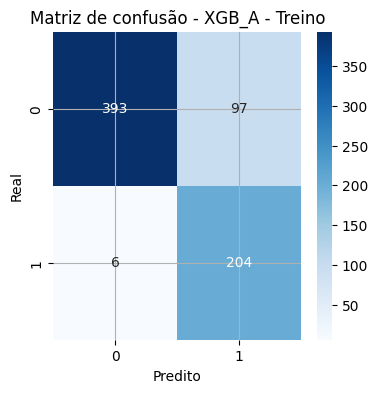


=== Métricas no TESTE (XGB_A) ===

================= Avaliação: XGB_A - Teste =================
Accuracy  : 0.6767
F1 (classe 1): 0.5571
Precision : 0.4729
Recall    : 0.6778
ROC AUC   : 0.7586
PR AUC    : 0.5866

Matriz de confusão:
[[142  68]
 [ 29  61]]


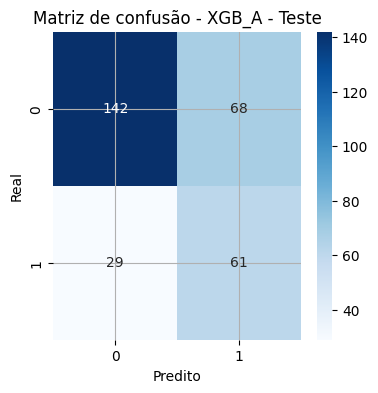


📈 Curvas ROC e PR no TESTE para XGB_A:


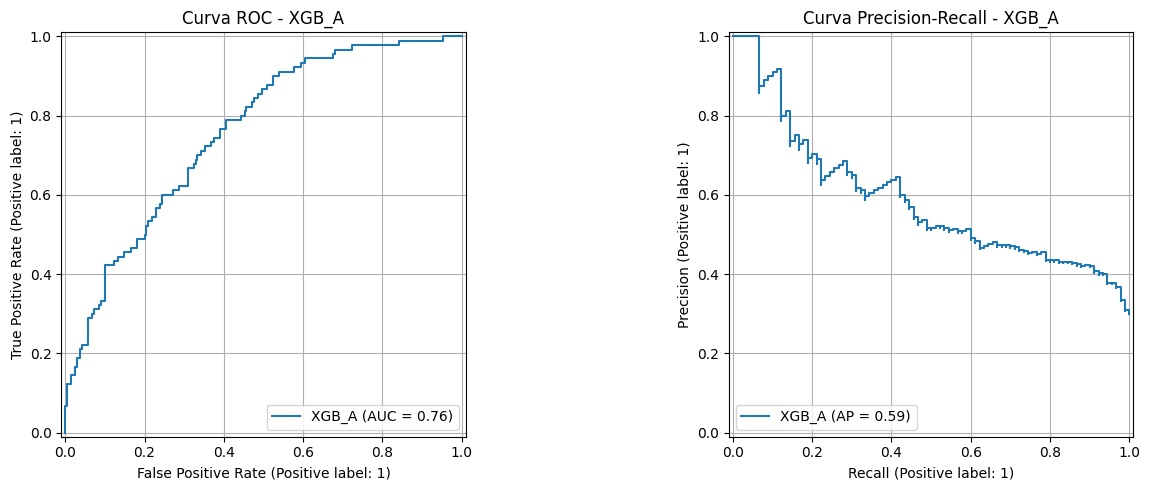


✅ Avaliação final do XGB_A concluída.


In [ ]:
# ======================================================================
# Célula 7: Avaliação XGBoost Linha A (treino e teste)
# ======================================================================

best_xgb_A = grid_xgb_A.best_estimator_

print("Reajustando XGB_A no conjunto de TREINO completo (já é feito pelo GridSearchCV, mas mantemos explícito).")
best_xgb_A.fit(X_train, y_train)

# Probabilidades e predições - TREINO
y_train_proba_xgb_A = best_xgb_A.predict_proba(X_train)[:, 1]
y_train_pred_xgb_A  = (y_train_proba_xgb_A >= 0.5).astype(int)

# Probabilidades e predições - TESTE
y_test_proba_xgb_A = best_xgb_A.predict_proba(X_test)[:, 1]
y_test_pred_xgb_A  = (y_test_proba_xgb_A >= 0.5).astype(int)

print("\n=== Métricas no TREINO (XGB_A) ===")
metrics_xgb_train_A = evaluate_model("XGB_A - Treino", y_train, y_train_pred_xgb_A, y_train_proba_xgb_A)

print("\n=== Métricas no TESTE (XGB_A) ===")
metrics_xgb_test_A = evaluate_model("XGB_A - Teste", y_test, y_test_pred_xgb_A, y_test_proba_xgb_A)

print("\n📈 Curvas ROC e PR no TESTE para XGB_A:")
plot_roc_pr_curves(y_test, y_test_proba_xgb_A, label="XGB_A")

print("\n✅ Avaliação final do XGB_A concluída.")


In [ ]:
# ======================================================================
# Célula 8: Função para construir a MLP no padrão SciKeras
# ======================================================================

def build_mlp_model(
    meta,
    hidden_layers=(64, 32),
    dropout_rate=0.3,
    use_batchnorm=True,
    l2_lambda=1e-4,
    activation="relu",
    learning_rate=1e-3,
):
    """
    Constrói um modelo MLP binário com hiperparâmetros configuráveis,
    compatível com SciKeras. O parâmetro `meta` traz infos como
    n_features_in_ (número de colunas de X).
    """
    # Número de features de entrada a partir dos metadados do SciKeras
    n_features = meta["n_features_in_"]

    model = keras.Sequential()
    # Camada de entrada explícita
    model.add(layers.InputLayer(input_shape=(n_features,)))

    # Camadas ocultas
    for units in hidden_layers:
        model.add(
            layers.Dense(
                units,
                activation=activation,
                kernel_regularizer=regularizers.l2(l2_lambda),
            )
        )
        if use_batchnorm:
          model.add(layers.BatchNormalization())
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    # Saída binária
    model.add(layers.Dense(1, activation="sigmoid"))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )

    return model

print("✅ Função build_mlp_model (versão SciKeras) definida.")


✅ Função build_mlp_model (versão SciKeras) definida.


In [ ]:
# ======================================================================
# Célula 9: Linha A - GridSearch da MLP com class_weight (sem SMOTE)
# ======================================================================

print("🔎 Iniciando GridSearch OTIMIZADO para MLP - Linha A (class_weight + scaler)...")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# KerasClassifier via SciKeras
mlp_A = KerasClassifier(
    model=build_mlp_model,
    # defaults (serão sobrescritos pelo grid onde indicado)
    hidden_layers=(64, 32),
    dropout_rate=0.3,
    use_batchnorm=True,
    l2_lambda=1e-4,
    activation="relu",
    learning_rate=1e-3,
    epochs=40,
    batch_size=128,
    random_state=RANDOM_STATE,
    verbose=0,
)

pipe_mlp_A = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("mlp", mlp_A),
])

# 🔥 GRID OTIMIZADO (16 combinações)
param_grid_mlp_A = {
    "mlp__hidden_layers": [
        (64, 32),
        (128, 64),
    ],
    "mlp__dropout_rate": [0.0, 0.3],
    "mlp__use_batchnorm": [True],
    "mlp__l2_lambda": [0.0, 1e-4],
    "mlp__activation": ["relu"],
    "mlp__learning_rate": [1e-3, 5e-3],
    "mlp__epochs": [40],
    "mlp__batch_size": [128],
}

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

grid_mlp_A = GridSearchCV(
    estimator=pipe_mlp_A,
    param_grid=param_grid_mlp_A,
    scoring=f1_pos_scorer,
    cv=cv,
    n_jobs=1,   # 👈 IMPORTANTÍSSIMO com TF para evitar problemas de multiprocess
    verbose=1,
)

grid_mlp_A.fit(
    X_train,
    y_train,
    mlp__class_weight=class_weight_dict,  # penalização do erro
    mlp__validation_split=0.2,
    mlp__callbacks=[early_stop_cb],
)

print("\n✅ GridSearch MLP Linha A concluído.")
print("Melhores hiperparâmetros (MLP_A):")
print(grid_mlp_A.best_params_)
print("Melhor F1 (validação) do MLP_A:", grid_mlp_A.best_score_)

results_mlp_A = pd.DataFrame(grid_mlp_A.cv_results_)
print("\n📌 Top 10 combinações do MLP_A por média do F1 (val):")
display(
    results_mlp_A.sort_values("mean_test_score", ascending=False)
                 .head(10)[[
                     "mean_test_score",
                     "param_mlp__hidden_layers",
                     "param_mlp__dropout_rate",
                     "param_mlp__use_batchnorm",
                     "param_mlp__l2_lambda",
                     "param_mlp__activation",
                     "param_mlp__learning_rate",
                 ]]
)
print("\n📌 Last 10 combinações do MLP_A por média do F1 (val):")
display(
    results_mlp_A.sort_values("mean_test_score", ascending=True)
                 .head(10)[[
                     "mean_test_score",
                     "param_mlp__hidden_layers",
                     "param_mlp__dropout_rate",
                     "param_mlp__use_batchnorm",
                     "param_mlp__l2_lambda",
                     "param_mlp__activation",
                     "param_mlp__learning_rate",
                 ]]
)


🔎 Iniciando GridSearch OTIMIZADO para MLP - Linha A (class_weight + scaler)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, i


✅ GridSearch MLP Linha A concluído.
Melhores hiperparâmetros (MLP_A):
{'mlp__activation': 'relu', 'mlp__batch_size': 128, 'mlp__dropout_rate': 0.0, 'mlp__epochs': 40, 'mlp__hidden_layers': (64, 32), 'mlp__l2_lambda': 0.0, 'mlp__learning_rate': 0.001, 'mlp__use_batchnorm': True}
Melhor F1 (validação) do MLP_A: nan

📌 Top 10 combinações do MLP_A por média do F1 (val):


,mean_test_score,param_mlp__hidden_layers,param_mlp__dropout_rate,param_mlp__use_batchnorm,param_mlp__l2_lambda,param_mlp__activation,param_mlp__learning_rate
0,NaN,"(64, 32)",0.0,True,0.0000,relu,0.001
1,NaN,"(64, 32)",0.0,True,0.0000,relu,0.005
2,NaN,"(64, 32)",0.0,True,0.0001,relu,0.001
3,NaN,"(64, 32)",0.0,True,0.0001,relu,0.005
4,NaN,"(128, 64)",0.0,True,0.0000,relu,0.001
5,NaN,"(128, 64)",0.0,True,0.0000,relu,0.005
6,NaN,"(128, 64)",0.0,True,0.0001,relu,0.001
7,NaN,"(128, 64)",0.0,True,0.0001,relu,0.005
8,NaN,"(64, 32)",0.3,True,0.0000,relu,0.001
9,NaN,"(64, 32)",0.3,True,0.0000,relu,0.005



📌 Last 10 combinações do MLP_A por média do F1 (val):


,mean_test_score,param_mlp__hidden_layers,param_mlp__dropout_rate,param_mlp__use_batchnorm,param_mlp__l2_lambda,param_mlp__activation,param_mlp__learning_rate
0,NaN,"(64, 32)",0.0,True,0.0000,relu,0.001
1,NaN,"(64, 32)",0.0,True,0.0000,relu,0.005
2,NaN,"(64, 32)",0.0,True,0.0001,relu,0.001
3,NaN,"(64, 32)",0.0,True,0.0001,relu,0.005
4,NaN,"(128, 64)",0.0,True,0.0000,relu,0.001
5,NaN,"(128, 64)",0.0,True,0.0000,relu,0.005
6,NaN,"(128, 64)",0.0,True,0.0001,relu,0.001
7,NaN,"(128, 64)",0.0,True,0.0001,relu,0.005
8,NaN,"(64, 32)",0.3,True,0.0000,relu,0.001
9,NaN,"(64, 32)",0.3,True,0.0000,relu,0.005


In [ ]:
grid_mlp_A.estimator.named_steps["mlp"].get_params().keys()


dict_keys(['model', 'build_fn', 'warm_start', 'random_state', 'optimizer', 'loss', 'metrics', 'batch_size', 'validation_batch_size', 'verbose', 'callbacks', 'validation_split', 'shuffle', 'run_eagerly', 'epochs', 'hidden_layers', 'dropout_rate', 'use_batchnorm', 'l2_lambda', 'activation', 'learning_rate', 'class_weight'])

🔁 Avaliando MLP Linha A (pipeline com scaler)...

=== Métricas no TREINO (MLP_A com ES) ===

================= Avaliação: MLP_A (ES) - Treino =================
Accuracy  : 0.9357
F1 (classe 1): 0.8843
Precision : 0.9609
Recall    : 0.8190
ROC AUC   : 0.9545
PR AUC    : 0.9471

Matriz de confusão:
[[483   7]
 [ 38 172]]


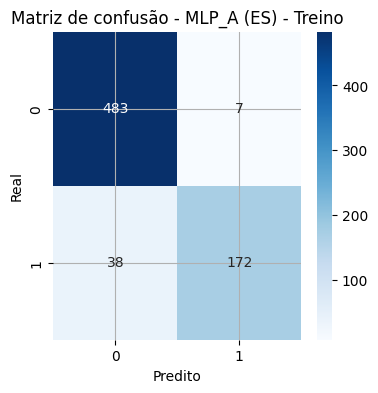


=== Métricas no TESTE (MLP_A com ES) ===

================= Avaliação: MLP_A (ES) - Teste =================
Accuracy  : 0.7233
F1 (classe 1): 0.4503
Precision : 0.5574
Recall    : 0.3778
ROC AUC   : 0.7306
PR AUC    : 0.4910

Matriz de confusão:
[[183  27]
 [ 56  34]]


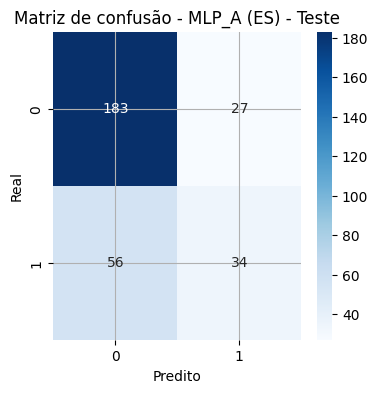

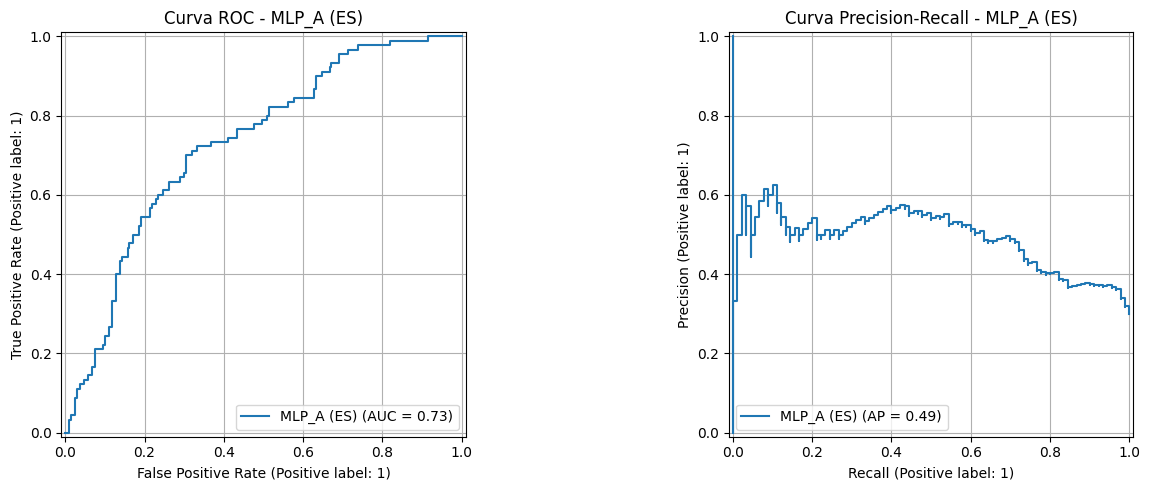


✅ Avaliação MLP Linha A concluída.


In [ ]:
# ======================================================================
# Célula 10: Avaliação MLP Linha A (com ES) e versão sem ES
# ======================================================================

print("🔁 Avaliando MLP Linha A (pipeline com scaler)...")

# Pegamos APENAS o scaler e o mlp (evita erro do Pipeline completo)
best_pipeline_A = grid_mlp_A.best_estimator_
scaler_A = best_pipeline_A.named_steps["scaler"]
best_mlp_A = best_pipeline_A.named_steps["mlp"]

# Aplicar o scaler explicitamente
X_train_scaled = scaler_A.transform(X_train)
X_test_scaled  = scaler_A.transform(X_test)

# Predições
y_train_proba_mlp_A = best_mlp_A.predict_proba(X_train_scaled)[:, 1]
y_train_pred_mlp_A  = (y_train_proba_mlp_A >= 0.5).astype(int)

y_test_proba_mlp_A = best_mlp_A.predict_proba(X_test_scaled)[:, 1]
y_test_pred_mlp_A  = (y_test_proba_mlp_A >= 0.5).astype(int)

print("\n=== Métricas no TREINO (MLP_A com ES) ===")
metrics_mlp_train_A = evaluate_model(
    "MLP_A (ES) - Treino",
    y_train,
    y_train_pred_mlp_A,
    y_train_proba_mlp_A
)

print("\n=== Métricas no TESTE (MLP_A com ES) ===")
metrics_mlp_test_A = evaluate_model(
    "MLP_A (ES) - Teste",
    y_test,
    y_test_pred_mlp_A,
    y_test_proba_mlp_A
)

plot_roc_pr_curves(y_test, y_test_proba_mlp_A, label="MLP_A (ES)")
print("\n✅ Avaliação MLP Linha A concluída.")


In [ ]:
# ======================================================================
# Célula 11: Linha B - XGBoost com SMOTE + TomekLinks
# ======================================================================

print("🔎 Iniciando GridSearch para XGBoost - Linha B (SMOTE + TomekLinks)...")

xgb_B = XGBClassifier(
    objective="binary:logistic",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist"
)

pipe_xgb_B = ImbPipeline(steps=[
    ("smote_tomek", SMOTETomek(random_state=RANDOM_STATE)),
    ("xgb", xgb_B)
])

param_grid_xgb_B = {
    "xgb__n_estimators": [300, 600],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.03, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__min_child_weight": [1, 5],
    "xgb__gamma": [0, 1],
    # aqui NÃO usamos scale_pos_weight para isolar efeito de SMOTE+Tomek
}

grid_xgb_B = GridSearchCV(
    estimator=pipe_xgb_B,
    param_grid=param_grid_xgb_B,
    scoring=f1_pos_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb_B.fit(X_train, y_train)

print("\n✅ GridSearch XGBoost Linha B concluído.")
print("Melhores hiperparâmetros (XGB_B):")
print(grid_xgb_B.best_params_)
print("Melhor F1 (validação) do XGB_B:", grid_xgb_B.best_score_)

results_xgb_B = pd.DataFrame(grid_xgb_B.cv_results_)
print("\n📌 Top 10 combinações do XGB_B por média do F1 (val):")
display(
    results_xgb_B.sort_values("mean_test_score", ascending=False)
                 .head(10)[["mean_test_score", "param_xgb__n_estimators",
                            "param_xgb__max_depth", "param_xgb__learning_rate",
                            "param_xgb__subsample", "param_xgb__colsample_bytree",
                            "param_xgb__min_child_weight", "param_xgb__gamma"]]
)
print("\n📌 Last 10 combinações do XGB_B por média do F1 (val):")
display(
    results_xgb_B.sort_values("mean_test_score", ascending=True)
                 .head(10)[["mean_test_score", "param_xgb__n_estimators",
                            "param_xgb__max_depth", "param_xgb__learning_rate",
                            "param_xgb__subsample", "param_xgb__colsample_bytree",
                            "param_xgb__min_child_weight", "param_xgb__gamma"]]
)

🔎 Iniciando GridSearch para XGBoost - Linha B (SMOTE + TomekLinks)...
Fitting 3 folds for each of 192 candidates, totalling 576 fits

✅ GridSearch XGBoost Linha B concluído.
Melhores hiperparâmetros (XGB_B):
{'xgb__colsample_bytree': 1.0, 'xgb__gamma': 1, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 300, 'xgb__subsample': 1.0}
Melhor F1 (validação) do XGB_B: 0.5541741015338763

📌 Top 10 combinações do XGB_B por média do F1 (val):


,mean_test_score,param_xgb__n_estimators,param_xgb__max_depth,param_xgb__learning_rate,param_xgb__subsample,param_xgb__colsample_bytree,param_xgb__min_child_weight,param_xgb__gamma
175,0.554174,600,3,0.10,1.0,1.0,5,1
173,0.554174,300,3,0.10,1.0,1.0,5,1
148,0.546591,300,3,0.03,0.8,1.0,5,1
34,0.546336,600,5,0.10,0.8,0.8,1,0
72,0.544264,300,3,0.10,0.8,0.8,1,1
80,0.543123,300,5,0.10,0.8,0.8,1,1
128,0.543107,300,5,0.10,0.8,1.0,1,0
74,0.539526,600,3,0.10,0.8,0.8,1,1
82,0.538369,600,5,0.10,0.8,0.8,1,1
94,0.538286,600,7,0.10,0.8,0.8,5,1



📌 Last 10 combinações do XGB_B por média do F1 (val):


,mean_test_score,param_xgb__n_estimators,param_xgb__max_depth,param_xgb__learning_rate,param_xgb__subsample,param_xgb__colsample_bytree,param_xgb__min_child_weight,param_xgb__gamma
47,0.474631,600,7,0.10,1.0,0.8,5,0
163,0.484297,600,7,0.03,1.0,1.0,1,1
161,0.484297,300,7,0.03,1.0,1.0,1,1
183,0.486163,600,5,0.10,1.0,1.0,5,1
181,0.486163,300,5,0.10,1.0,1.0,5,1
135,0.491131,600,5,0.10,1.0,1.0,5,0
191,0.492495,600,7,0.10,1.0,1.0,5,1
189,0.492495,300,7,0.10,1.0,1.0,5,1
112,0.493797,300,7,0.03,0.8,1.0,1,0
45,0.494529,300,7,0.10,1.0,0.8,5,0



=== Métricas no TREINO (XGB_B) ===

================= Avaliação: XGB_B - Treino =================
Accuracy  : 0.8571
F1 (classe 1): 0.7487
Precision : 0.7926
Recall    : 0.7095
ROC AUC   : 0.9028
PR AUC    : 0.8098

Matriz de confusão:
[[451  39]
 [ 61 149]]


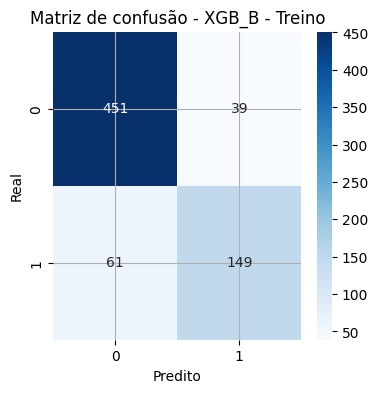


=== Métricas no TESTE (XGB_B) ===

================= Avaliação: XGB_B - Teste =================
Accuracy  : 0.7067
F1 (classe 1): 0.4824
Precision : 0.5125
Recall    : 0.4556
ROC AUC   : 0.7436
PR AUC    : 0.5377

Matriz de confusão:
[[171  39]
 [ 49  41]]


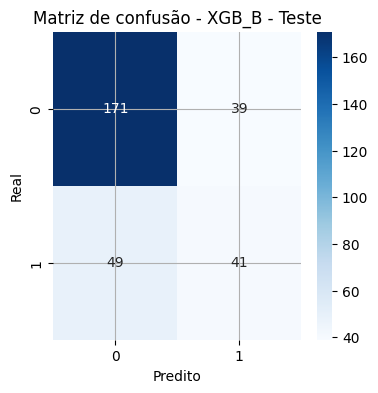


📈 Curvas ROC e PR no TESTE para XGB_B:


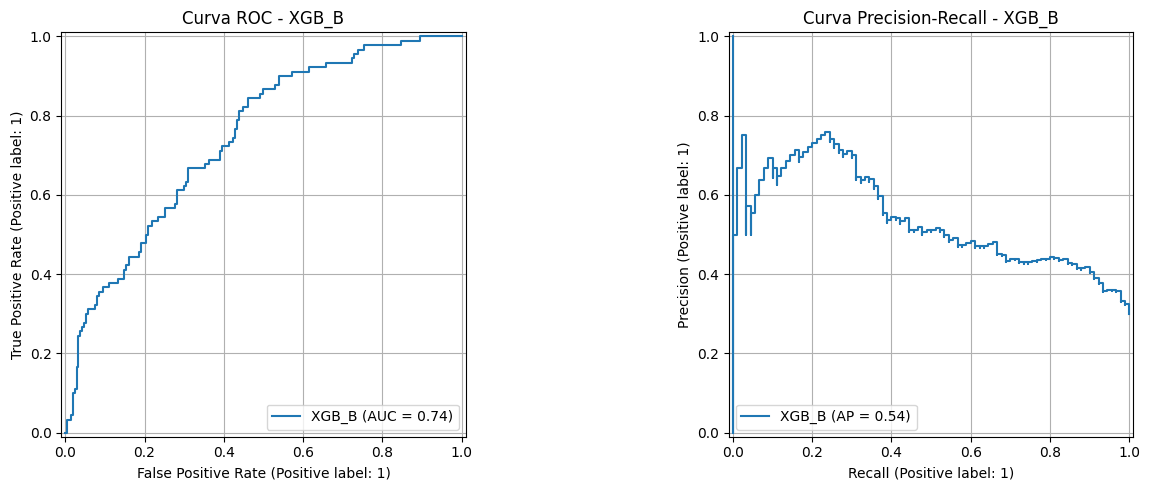


✅ Avaliação final do XGB_B concluída.


In [ ]:
# ======================================================================
# Célula 12: Avaliação XGBoost Linha B (treino e teste)
# ======================================================================

best_xgb_B = grid_xgb_B.best_estimator_

# Predição/proba no TREINO
y_train_proba_xgb_B = best_xgb_B.predict_proba(X_train)[:, 1]
y_train_pred_xgb_B  = (y_train_proba_xgb_B >= 0.5).astype(int)

# Predição/proba no TESTE
y_test_proba_xgb_B = best_xgb_B.predict_proba(X_test)[:, 1]
y_test_pred_xgb_B  = (y_test_proba_xgb_B >= 0.5).astype(int)

print("\n=== Métricas no TREINO (XGB_B) ===")
metrics_xgb_train_B = evaluate_model("XGB_B - Treino", y_train, y_train_pred_xgb_B, y_train_proba_xgb_B)

print("\n=== Métricas no TESTE (XGB_B) ===")
metrics_xgb_test_B = evaluate_model("XGB_B - Teste", y_test, y_test_pred_xgb_B, y_test_proba_xgb_B)

print("\n📈 Curvas ROC e PR no TESTE para XGB_B:")
plot_roc_pr_curves(y_test, y_test_proba_xgb_B, label="XGB_B")

print("\n✅ Avaliação final do XGB_B concluída.")


In [ ]:
# ======================================================================
# Célula 13 (REVISADA): Linha B - MLP com SMOTE + TomekLinks
# ======================================================================

from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

print("🔎 Iniciando GridSearch OTIMIZADO para MLP - Linha B (SMOTE + TomekLinks)...")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# KerasClassifier via SciKeras
# 🔴 IMPORTANTE: declarar todos os hiperparâmetros aqui
mlp_B = KerasClassifier(
    model=build_mlp_model,   # mesma função da Célula 8 (com meta['n_features_in_'])
    hidden_layers=(64, 32),
    dropout_rate=0.3,
    use_batchnorm=True,
    l2_lambda=1e-4,
    activation="relu",
    learning_rate=1e-3,
    epochs=40,
    batch_size=128,
    random_state=RANDOM_STATE,
    verbose=0,
)

pipe_mlp_B = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote_tomek", SMOTETomek(random_state=RANDOM_STATE)),
    ("mlp", mlp_B),
])

# 🔥 GRID OTIMIZADO (16 combinações: 2x2x2x2)
param_grid_mlp_B = {
    "mlp__hidden_layers": [
        (64, 32),
        (128, 64),
    ],
    "mlp__dropout_rate": [0.0, 0.3],
    "mlp__l2_lambda": [0.0, 1e-4],
    "mlp__learning_rate": [1e-3, 5e-3],
    # fixamos:
    #   use_batchnorm=True
    #   activation="relu"
    #   epochs=40
    #   batch_size=128
}

early_stop_cb_B = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

grid_mlp_B = GridSearchCV(
    estimator=pipe_mlp_B,
    param_grid=param_grid_mlp_B,
    scoring=f1_pos_scorer,
    cv=cv,
    n_jobs=1,   # 👈 evita conflito TF + multiprocess
    verbose=1,
)

grid_mlp_B.fit(
    X_train,
    y_train,
    mlp__validation_split=0.2,
    mlp__callbacks=[early_stop_cb_B],
)

print("\n✅ GridSearch MLP Linha B concluído.")
print("Melhores hiperparâmetros (MLP_B):")
print(grid_mlp_B.best_params_)
print("Melhor F1 (validação) do MLP_B:", grid_mlp_B.best_score_)

results_mlp_B = pd.DataFrame(grid_mlp_B.cv_results_)
print("\n📌 Top 10 combinações do MLP_B por média do F1 (val):")
display(
    results_mlp_B.sort_values("mean_test_score", ascending=False)
                 .head(10)[[
                     "mean_test_score",
                     "param_mlp__hidden_layers",
                     "param_mlp__dropout_rate",
                     "param_mlp__l2_lambda",
                     "param_mlp__learning_rate",
                 ]]
)
print("\n📌 Last 10 combinações do MLP_B por média do F1 (val):")
display(
    results_mlp_B.sort_values("mean_test_score", ascending=True)
                 .head(10)[[
                       "mean_test_score",
                     "param_mlp__hidden_layers",
                     "param_mlp__dropout_rate",
                     "param_mlp__l2_lambda",
                     "param_mlp__learning_rate",
                            ]]
)


🔎 Iniciando GridSearch OTIMIZADO para MLP - Linha B (SMOTE + TomekLinks)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, i


✅ GridSearch MLP Linha B concluído.
Melhores hiperparâmetros (MLP_B):
{'mlp__dropout_rate': 0.0, 'mlp__hidden_layers': (64, 32), 'mlp__l2_lambda': 0.0, 'mlp__learning_rate': 0.001}
Melhor F1 (validação) do MLP_B: nan

📌 Top 10 combinações do MLP_B por média do F1 (val):


,mean_test_score,param_mlp__hidden_layers,param_mlp__dropout_rate,param_mlp__l2_lambda,param_mlp__learning_rate
0,NaN,"(64, 32)",0.0,0.0000,0.001
1,NaN,"(64, 32)",0.0,0.0000,0.005
2,NaN,"(64, 32)",0.0,0.0001,0.001
3,NaN,"(64, 32)",0.0,0.0001,0.005
4,NaN,"(128, 64)",0.0,0.0000,0.001
5,NaN,"(128, 64)",0.0,0.0000,0.005
6,NaN,"(128, 64)",0.0,0.0001,0.001
7,NaN,"(128, 64)",0.0,0.0001,0.005
8,NaN,"(64, 32)",0.3,0.0000,0.001
9,NaN,"(64, 32)",0.3,0.0000,0.005



📌 Last 10 combinações do MLP_B por média do F1 (val):


,mean_test_score,param_mlp__hidden_layers,param_mlp__dropout_rate,param_mlp__l2_lambda,param_mlp__learning_rate
0,NaN,"(64, 32)",0.0,0.0000,0.001
1,NaN,"(64, 32)",0.0,0.0000,0.005
2,NaN,"(64, 32)",0.0,0.0001,0.001
3,NaN,"(64, 32)",0.0,0.0001,0.005
4,NaN,"(128, 64)",0.0,0.0000,0.001
5,NaN,"(128, 64)",0.0,0.0000,0.005
6,NaN,"(128, 64)",0.0,0.0001,0.001
7,NaN,"(128, 64)",0.0,0.0001,0.005
8,NaN,"(64, 32)",0.3,0.0000,0.001
9,NaN,"(64, 32)",0.3,0.0000,0.005


🔁 Avaliando MLP Linha B (SMOTE + TomekLinks)...

=== Métricas no TREINO (MLP_B) ===

================= Avaliação: MLP_B - Treino =================
Accuracy  : 0.9595
F1 (classe 1): 0.9578
Precision : 1.0000
Recall    : 0.9191
ROC AUC   : 0.9991
PR AUC    : 0.9991

Matriz de confusão:
[[482   0]
 [ 39 443]]


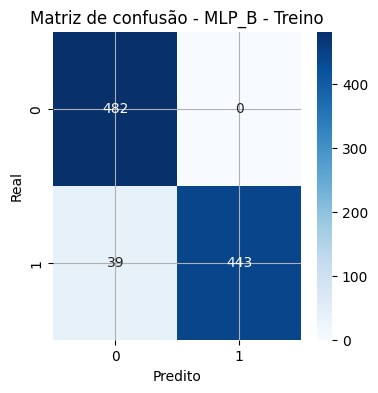


=== Métricas no TESTE (MLP_B) ===

================= Avaliação: MLP_B - Teste =================
Accuracy  : 0.7500
F1 (classe 1): 0.5399
Precision : 0.6027
Recall    : 0.4889
ROC AUC   : 0.7745
PR AUC    : 0.5141

Matriz de confusão:
[[181  29]
 [ 46  44]]


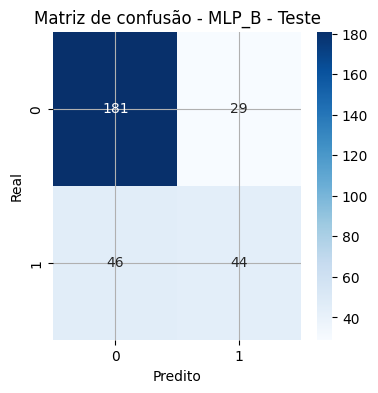


📈 Curvas ROC e PR no TESTE para MLP_B:


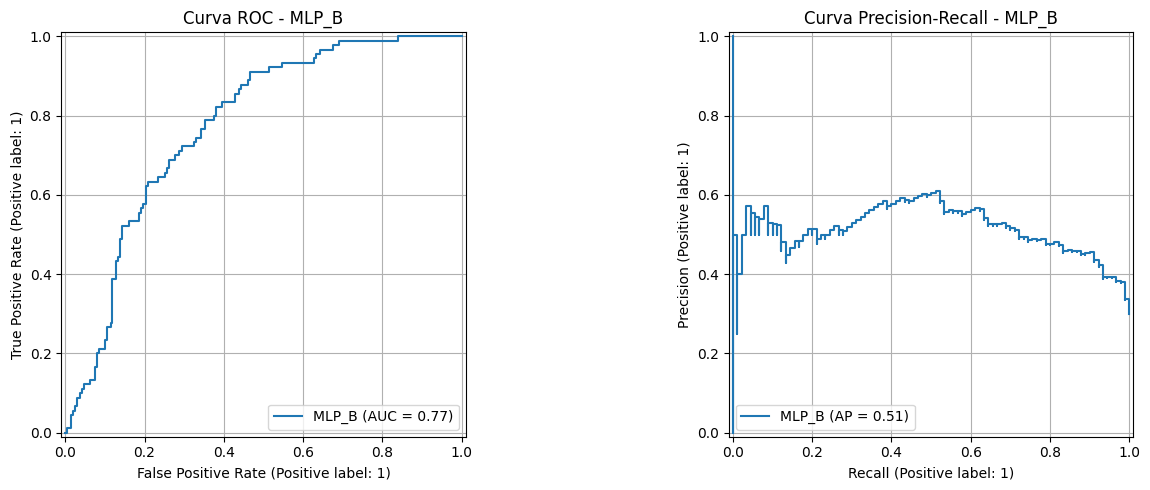


✅ Avaliação final do MLP_B concluída (SEM erro).


In [ ]:
# ======================================================================
# Célula 14: Avaliação MLP Linha B (treino e teste)
# ======================================================================

print("🔁 Avaliando MLP Linha B (SMOTE + TomekLinks)...")

# Pegamos o pipeline completo
best_pipeline_B = grid_mlp_B.best_estimator_

# Extraímos cada passo manualmente
scaler_B       = best_pipeline_B.named_steps["scaler"]
smote_tomek_B  = best_pipeline_B.named_steps["smote_tomek"]
mlp_B_best     = best_pipeline_B.named_steps["mlp"]

# 1) Transformamos X_train e X_test EXATAMENTE como o pipeline faria:

# 1a. Escala (apenas no treino, fitted no treino)
X_train_scaled = scaler_B.transform(X_train)
X_test_scaled  = scaler_B.transform(X_test)

# 1b. SMOTE + TomekLinks (⚠️ só no TREINO!)
X_train_bal, y_train_bal = smote_tomek_B.fit_resample(X_train_scaled, y_train)

# ❗ Importante:
# NUNCA aplicar SMOTE no teste – apenas no treino.

# 2) Predições usando APENAS o modelo interno (mlp_B_best)

# TREINO (balan ceado)
y_train_proba_mlp_B = mlp_B_best.predict_proba(X_train_bal)[:, 1]
y_train_pred_mlp_B  = (y_train_proba_mlp_B >= 0.5).astype(int)

# TESTE (normal)
y_test_proba_mlp_B = mlp_B_best.predict_proba(X_test_scaled)[:, 1]
y_test_pred_mlp_B  = (y_test_proba_mlp_B >= 0.5).astype(int)

# 3) Avaliar
print("\n=== Métricas no TREINO (MLP_B) ===")
metrics_mlp_train_B = evaluate_model("MLP_B - Treino",
                                     y_train_bal,
                                     y_train_pred_mlp_B,
                                     y_train_proba_mlp_B)

print("\n=== Métricas no TESTE (MLP_B) ===")
metrics_mlp_test_B = evaluate_model("MLP_B - Teste",
                                    y_test,
                                    y_test_pred_mlp_B,
                                    y_test_proba_mlp_B)

print("\n📈 Curvas ROC e PR no TESTE para MLP_B:")
plot_roc_pr_curves(y_test, y_test_proba_mlp_B, label="MLP_B")

print("\n✅ Avaliação final do MLP_B concluída (SEM erro).")


In [ ]:
# ======================================================================
# Célula 15: Comparação final entre modelos e linhas A/B
# ======================================================================

rows = []

def add_row(name, metrics_train, metrics_test):
    rows.append({
        "Modelo": name,
        "Acc_train": metrics_train["accuracy"],
        "Acc_test": metrics_test["accuracy"],
        "F1_train": metrics_train["f1"],
        "F1_test": metrics_test["f1"],
        "Prec_test": metrics_test["precision"],
        "Recall_test": metrics_test["recall"],
    })

add_row("XGB_A",      metrics_xgb_train_A,  metrics_xgb_test_A)
add_row("XGB_B",      metrics_xgb_train_B,  metrics_xgb_test_B)
add_row("MLP_A (ES)", metrics_mlp_train_A,  metrics_mlp_test_A)
# add_row("MLP_A (sem ES)", metrics_mlp_train_A_no_es, metrics_mlp_test_A_no_es)
add_row("MLP_B (ES)", metrics_mlp_train_B,  metrics_mlp_test_B)

df_summary = pd.DataFrame(rows)
print("📌 Comparação final de desempenho (treino x teste):")
display(df_summary.sort_values("F1_test", ascending=False))

print("\n✅ Pipeline experimental completo executado.")


📌 Comparação final de desempenho (treino x teste):


,Modelo,Acc_train,Acc_test,F1_train,F1_test,Prec_test,Recall_test
0,XGB_A,0.852857,0.676667,0.798434,0.557078,0.472868,0.677778
3,MLP_B (ES),0.959544,0.750000,0.957838,0.539877,0.602740,0.488889
1,XGB_B,0.857143,0.706667,0.748744,0.482353,0.512500,0.455556
2,MLP_A (ES),0.935714,0.723333,0.884319,0.450331,0.557377,0.377778



✅ Pipeline experimental completo executado.
